# Inflation Trends in the United States (2004 – Present)

## Consumer Price Index (CPI) vs. Core CPI Year-over-Year

### Description

This notebook provides a technical visualization of U.S. inflationary trends over the past two decades. Utilizing data retrieved from the Federal Reserve Economic Data (FRED) system, it evaluates and contrasts two primary macroeconomic metrics:

- **Headline CPI (All Urban Consumers | FRED: CPIAUCSL):** Reflects the price changes of a representative basket of goods and services, capturing aggregate consumer price movements.
- **Core CPI (All Items Less Food and Energy | FRED: CPILFESL):** Isolates the structural, long-term inflation trend by stripping away historically volatile food and energy commodity components.

The analysis is conducted using year-over-year (YoY) percentage changes, allowing for a smoothed structural overview of consumer purchasing power and underlying macroeconomic momentum.

---

## Objectives

- **Long-Term Trend Analysis:** Evaluate structural inflation patterns from 2004 through the present day.
- **Metric Variance:** Compare the sensitivity and decoupling behavior of headline inflation versus core inflation during commodity shocks.
- **Macroeconomic Chronology:** Identify and map specific historical periods of structural inflation acceleration (reflation/hyper-demand) and deceleration (disinflation/deflation).
- **Policy Contextualization:** Provide a data-driven timeline mapping inflation fluctuations to Federal Reserve monetary cycles and global economic events.

---

## Data Source

- **Federal Reserve Economic Data (FRED)**  
  - `CPIAUCSL`: Consumer Price Index for All Urban Consumers: All Items  
  - `CPILFESL`: Consumer Price Index for All Urban Consumers: All Items Less Food and Energy  
  - `DPCCRV1A225NBEA`: Personal Consumption Expenditures (PCE) Excluding Food and Energy (chain-type price index)  
  - `PCETRIM12M159SFRBDAL`: Trimmed Mean PCE Inflation Rate

---

## CPI Inflation (2004–Present): Historical Chronology

### Major Macroeconomic Events Impacting Trends:
- **2008 Great Recession & Housing Market Collapse:** Sharp contraction in aggregate demand leading to historical disinflationary/deflationary pressures.
- **2020 COVID-19 Pandemic:** Initial deflationary shock followed by massive global supply-chain disruptions and unprecedented fiscal stimulus.
- **2021–2023 Post-Pandemic Inflationary Surge:** A historic peak in global inflation driven by surging consumer demand, structural labor shortages, and energy market imbalances.
- **2022–2024 Fed Monetary Tightening Cycle:** Aggressive interest rate hikes enacted by the Federal Reserve to cool demand and anchor long-term inflation expectations back to the 2.0% target.
- **Global Geopolitical Friction (2022–Present):** Supply chain friction and commodity shocks amplified by the Russia-Ukraine war and escalating conflicts in the Middle East.

## Pre-Processing

### Install System Dependencies

In [2]:
!pip install pandas-datareader
# Note: Uncomment below if necessary to ugrade installer
# !pip3 install --upgrade pip

### Import Python Libraries

In [3]:
import pandas as pd
import pandas_datareader.data as web
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta

### Define Global Functions 

In [4]:
def add_event_lines(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=10,
                     fontweight='bold')
            
def add_event_lines_small(events, df_plot, y_position):
    """
    Plots vertical lines and labels for specific events within the date range of df_plot.
    
    Parameters:
    - events (dict): A dictionary of {'date_string': 'label'}.
    - df_plot (DataFrame): The pandas DataFrame being plotted (expects a DatetimeIndex).
    - y_position (float): The y-axis coordinate for the text labels.
    """
    for date_str, label in events.items():
        evt_date = pd.to_datetime(date_str)
        
        if df_plot.index.min() <= evt_date <= df_plot.index.max():
            plt.axvline(x=evt_date, 
                        color='black', 
                        linestyle=':', 
                        linewidth=1.2, 
                        alpha=0.7)
            
            plt.text(evt_date, y_position, label,
                     rotation=90, 
                     verticalalignment='top',
                     horizontalalignment='right',
                     fontsize=5,
                     fontweight='bold')

### Standard Unit Initial Timeframe

In [5]:
start = datetime(2005, 1, 1)
end = datetime.now()
str_current_date = end.strftime("%B %d, %Y")
plot_start = start + relativedelta(years=1)

## CPI Inflation: 20-Year Historical

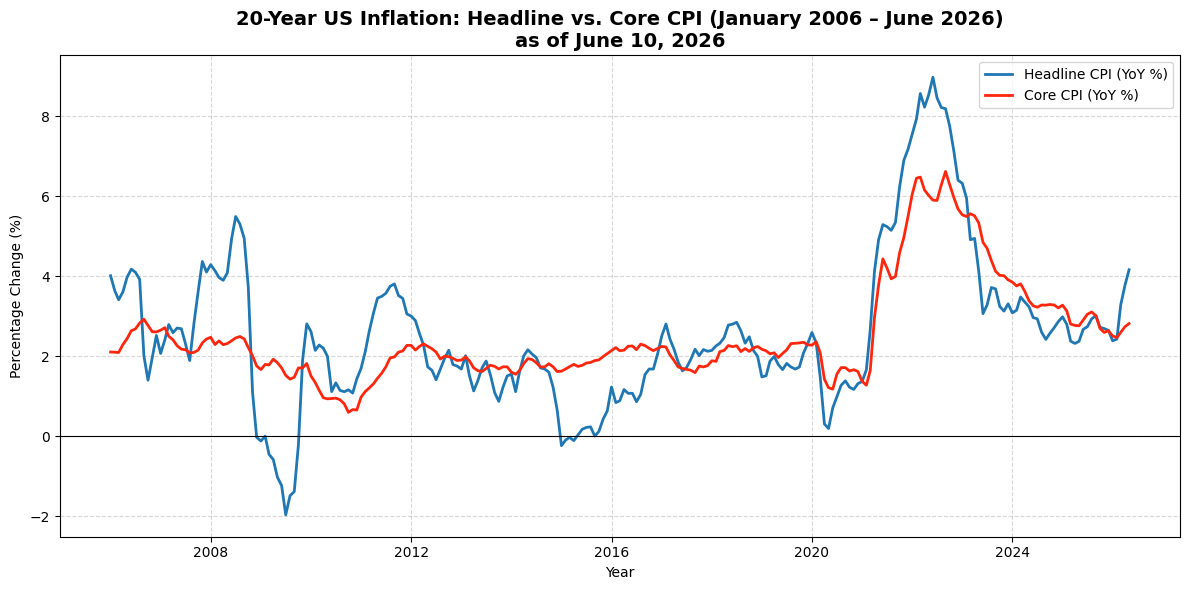

In [6]:
cpi_series = {
'CPIAUCSL': 'CPI for All Urban Consumers: All Items', 
'CPILFESL': 'CPI for All Urban Consumers: All Items Less Food and Energy'
}

df = web.DataReader(list(cpi_series.keys()), 'fred', start, end)
df.rename(columns=cpi_series, inplace=True)
df = df.ffill()

df_yoy = df.pct_change(periods=12) * 100

plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

# plot formatting
plt.title(f'20-Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()

plt.show()

## 10-Year Historical Index
- 2008 Finanical Housing Crisis
- COVID-19 Pandemic
- Start of Iran War

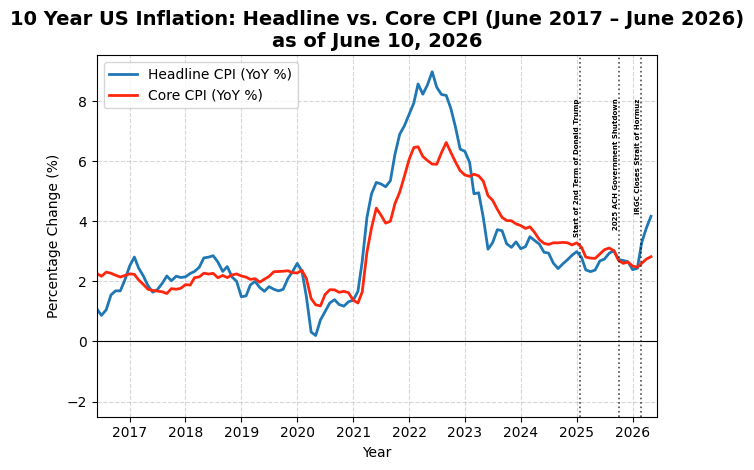

In [32]:
# timeframe
start = datetime(2016, 6, 1)

plot_start = start + relativedelta(years=1)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.85

events = {
'2007-12-01': '2008 U.S. Housing Crisis Recession',
'2020-03-01': 'COVID-19 Global Pandemic',
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# plot formatting
plt.title(f'10 Year US Inflation: Headline vs. Core CPI ({plot_start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlim(start,end)
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines_small(events , df, y)
plt.legend()
plt.tight_layout()

plt.show()

## CPI Inflation (June 2022-Present)
### Key Events
- Presidential Inauguration of Donald J. Trump's as the 47th President of the United States of America.
- Effective start of President Trump's global tariffs policy.
- U.S. Congressional 43-day shutdown.
- Iran closed the Straight of Hormuz.

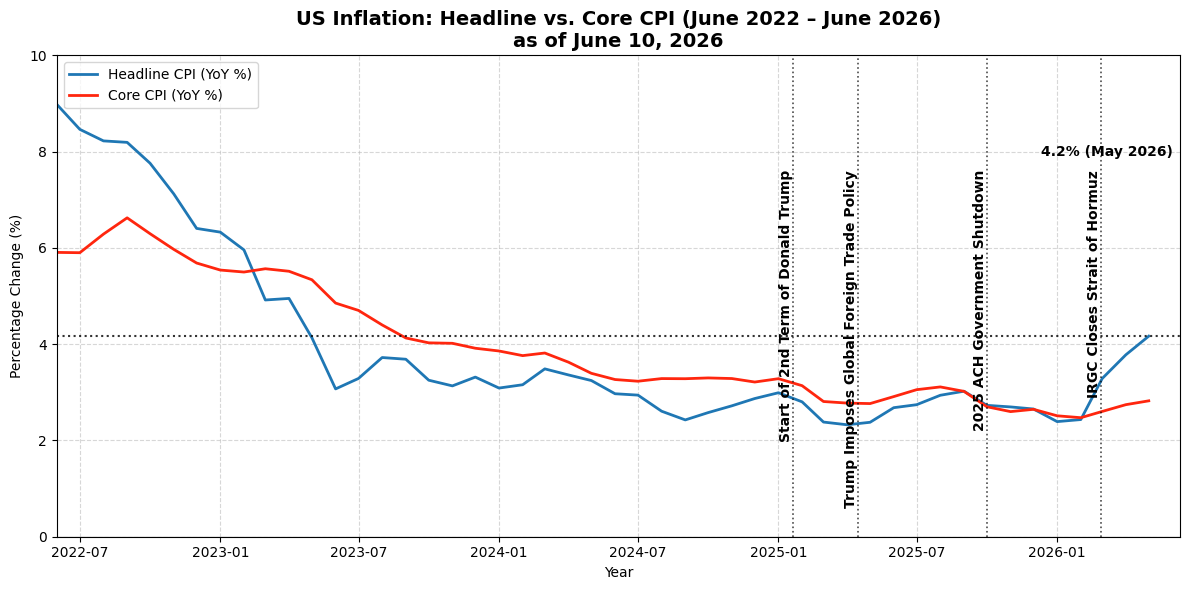

In [28]:
events = {
'2025-01-20': 'Start of 2nd Term of Donald Trump',
'2025-4-15': 'Trump Imposes Global Foreign Trade Policy',
'2025-10-01': '2025 ACH Government Shutdown',
'2026-02-28': 'IRGC Closes Strait of Hormuz'
}

# values
r_date = df_yoy['CPI for All Urban Consumers: All Items'].dropna().index[-1]
r_val = df_yoy['CPI for All Urban Consumers: All Items'].dropna().iloc[-1]

# timeframe
start = datetime(2022, 6, 1)
plot_start = start + relativedelta(years=1)

# Plot
plt.figure(figsize=(12, 6))

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items'],
        label='Headline CPI (YoY %)', 
        color='#1f77b4', 
        linewidth=2)

plt.plot(df_yoy.index, 
        df_yoy['CPI for All Urban Consumers: All Items Less Food and Energy'],
        label='Core CPI (YoY %)', 
        color="#ff260e", 
        linewidth=2)

y = plt.ylim()[1]*0.8

# Formatting
plt.title(f'US Inflation: Headline vs. Core CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percentage Change (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xlim(start, end)
plt.ylim(0,10)
add_event_lines(events, df, y)
plt.annotate(f"{r_val:.1f}% ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-30,130), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.axhline(y=r_val, 
            color="#000000", 
            linestyle=':', 
            linewidth=1.5, 
            alpha=0.8)

plt.legend()
plt.tight_layout()

plt.show()

## Personal Consumption Expenditures (PCE)

### Real Personal Consumption Expenditures Per Capita: 10-Year Historical 

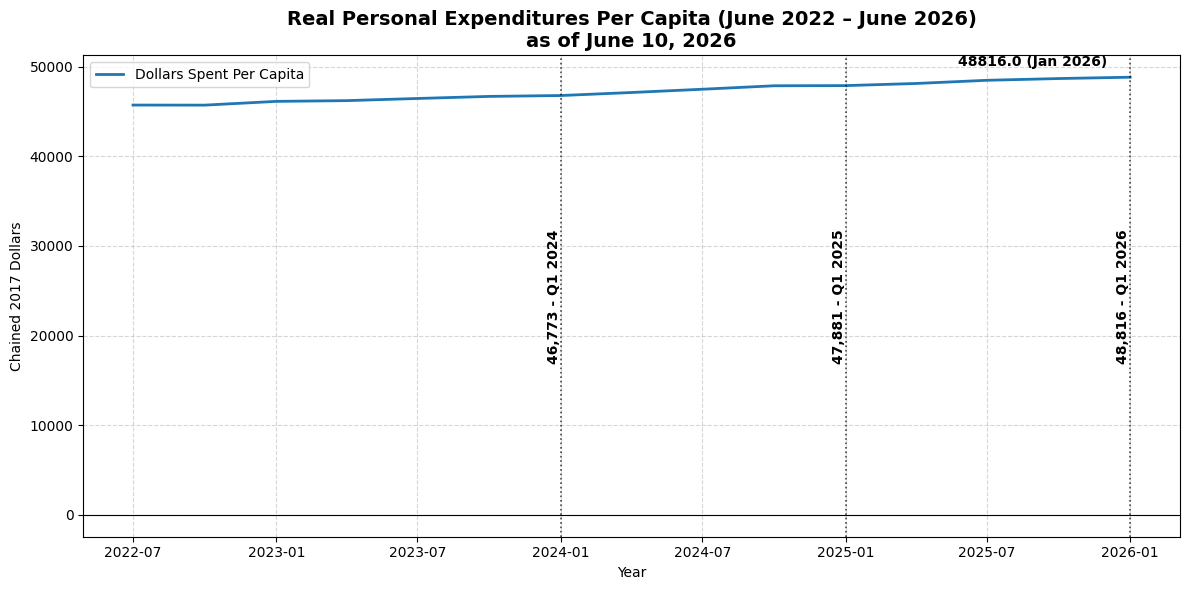

In [17]:
# source: FRED
df = web.DataReader('A794RX0Q048SBEA', 'fred', start, end)

# values
r_date = df['A794RX0Q048SBEA'].dropna().index[-1]
r_val = df['A794RX0Q048SBEA'].dropna().iloc[-1]

# Plot
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['A794RX0Q048SBEA'], 
         label="Dollars Spent Per Capita", 
         color='#1f77b4', 
         linewidth=2)

y = plt.ylim()[1]*0.65

# Q1 2016-2026
fyq_s1 = {
    '2016-01-1': '39,667 - Q1 2016',
    '2020-01-1': '41,886 - Q1 2020',
    '2024-01-1': '46,773 - Q1 2024',
    '2025-01-1': '47,881 - Q1 2025',
    '2026-01-1': '48,816 - Q1 2026'
}

plt.title(f'Real Personal Expenditures Per Capita ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
add_event_lines(fyq_s1, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-70,8), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')
plt.legend()
plt.tight_layout()

plt.show()

### Consumer Price Index for All Urban Consumers: 5-Year Historical

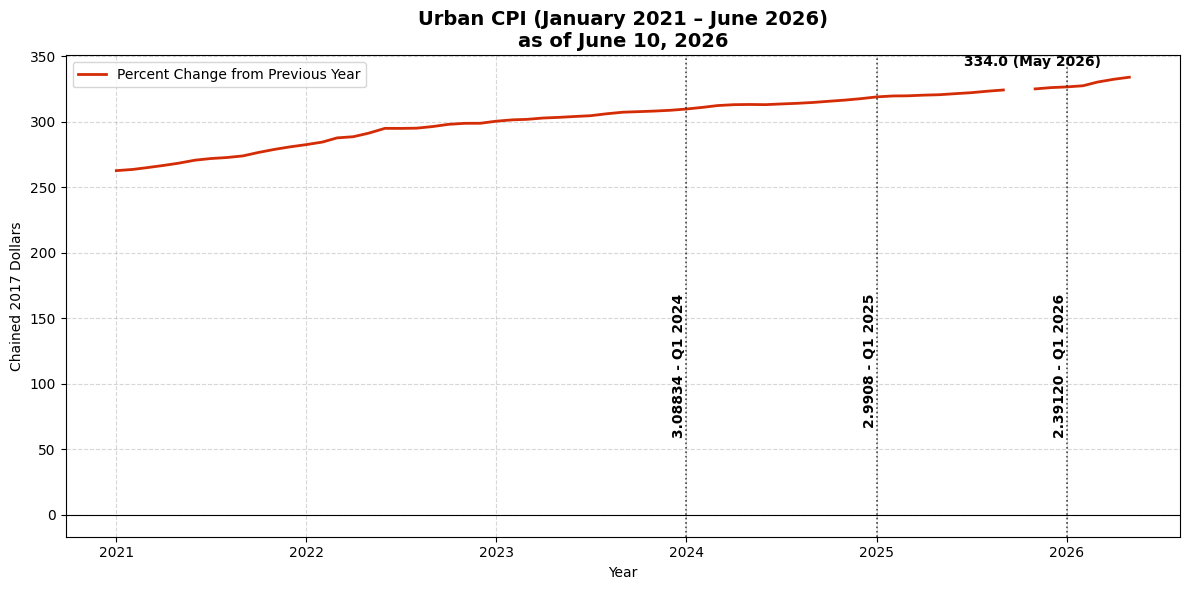

In [20]:
# source
df = web.DataReader('CPIAUCSL', 'fred', start, end)

# values
r_date = df['CPIAUCSL'].dropna().index[-1]
r_val = df['CPIAUCSL'].dropna().iloc[-1]

# timeframe
start = datetime(2021, 1, 1)
plot_start = start + relativedelta(years=1)

# Plotting
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['CPIAUCSL'], 
         label="Percent Change from Previous Year", 
         color="#d42c06", 
         linewidth=2)

y = plt.ylim()[1]*0.5

# Event Markers
fyq_s2 = {
    '2024-01-1': '3.08834 - Q1 2024',
    '2025-01-1': '2.9908 - Q1 2025',
    '2026-01-1': '2.39120 - Q1 2026'
}

plt.title(f'Urban CPI ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Chained 2017 Dollars')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s2, df, y)
plt.annotate(f"{r_val:.1f} ({r_date.strftime('%b %Y')})", 
             (r_date, r_val), 
             textcoords = "offset points", 
             xytext = (-70,8), 
             ha = 'center', 
             weight = 'bold', 
             color = 'black')


plt.show()

### Trimmed Mean PCE and PCE Inflation Rate: 5-Year Historical 

/var/folders/71/ng2k1j0j5zl7wss17qgbmsfr0000gn/T/ipykernel_27608/630267459.py:11: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100


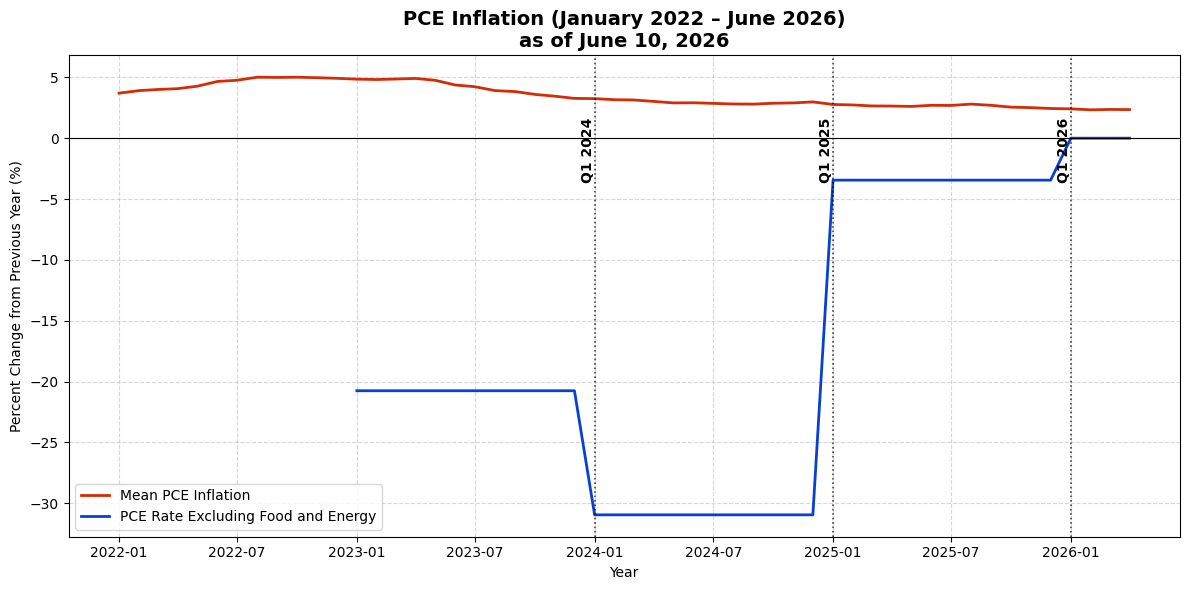

In [22]:
rate_series = {
    'PCETRIM12M159SFRBDAL': 'Trimmed Mean PCE Inflation Rate',
    'DPCCRV1A225NBEA': 'PCE Inflation Rate Excluding Food and Energy',
}

df_raw = web.DataReader(list(rate_series.keys()), 'fred', start, end)
df_raw.rename(columns=rate_series, inplace=True)

df_rate = pd.DataFrame()
df_rate['Trimmed Mean PCE Inflation Rate'] = df_raw['Trimmed Mean PCE Inflation Rate']
df_rate['PCE Rate Excluding Food and Energy'] = df_raw['PCE Inflation Rate Excluding Food and Energy'].pct_change(12) * 100

start = datetime(2022, 1, 1)
plot_start = start + relativedelta(years=1)

plt.figure(figsize=(12, 6))
plt.plot(df_rate.index, 
         df_rate['Trimmed Mean PCE Inflation Rate'], 
         label="Mean PCE Inflation", 
         color="#d42c06", 
         linewidth=2)

plt.plot(df_rate.index, df_rate['PCE Rate Excluding Food and Energy'], 
         label="PCE Rate Excluding Food and Energy", 
         color="#0640d4", 
         linewidth=2)

y = plt.ylim()[1]*0.25

# Event Markers
fyq_s3 = {
    '2024-01-1': 'Q1 2024',
    '2025-01-1': 'Q1 2025',
    '2026-01-1': 'Q1 2026'
}

plt.title(f'PCE Inflation ({start.strftime("%B %Y")} – {end.strftime("%B %Y")})\nas of {str_current_date}', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Percent Change from Previous Year (%)')
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
add_event_lines(fyq_s3,df,y)

plt.show()

# Conclusions and Observations

***In Progress***

## Update Schedule
### 1) Producer Price Index (PPI): Thursday, June 11, 2026, at 8:30 A.Ms. Eastern Time.

### 2) Personal Consumption Expenditures (PCE) Index: Wednesday, June 25, 2026.

#### ***Review and analysis publishing on Friday, June 14, 2026, at 1:30 P.M. Pacific Time.***